# Notebook 05 — Final Visualizations

This notebook produces all charts and interactive maps for the final project.

## 0. Imports and shared configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from helper_functions import safe_wkt_load
import pandas as pd
import geopandas as gpd
from shapely import wkt
import plotly.graph_objects as go

# Paths — notebook lives in scripts/, data and visualizations are one level up
PROCESSED = Path("../data/processed")
VIZ = Path("../visualizations")
VIZ.mkdir(exist_ok=True)

# Route display settings shared across all charts
SELECTED_ROUTES = ["22", "Rapid 522", "23", "Rapid 523", "25", "60"]

ROUTE_COLORS_STR = {
    "22": "#8c2d04",
    "Rapid 522": "#cc4c02",
    "23": "#ec7014",
    "Rapid 523": "#fe9929",
    "25": "#fec44f",
    "60": "#a6611a",
}

ROUTE_COLORS_INT = {int(k.replace("Rapid ", "")): v for k, v in ROUTE_COLORS_STR.items()}

print("Imports complete.")

Imports complete.


In [2]:
# Shared style for all charts — clean and professional
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#444",
    "axes.linewidth": 0.8,
    "xtick.color": "#444",
    "ytick.color": "#444",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Refined route palette — earth tones, more cohesive
ROUTE_COLORS_STR = {
    "22":        "#7a3f12",
    "Rapid 522": "#c25a1f",
    "23":        "#e08530",
    "Rapid 523": "#f0b860",
    "25":        "#d4a017",
    "60":        "#8b6a3d",
}
ROUTE_COLORS_INT = {int(k.replace("Rapid ", "")): v for k, v in ROUTE_COLORS_STR.items()}

## 1. Load processed data

In [3]:
# Delay records (one row per trip-stop observation)
delay_raw = pd.read_csv(PROCESSED / "cleaned_delay_data.csv")

# Stop-level ridership
ridership = pd.read_csv(PROCESSED / "selected_station_ridership.csv")
ridership["direction_id"] = ridership["direction_id"] % 10

# Unified stop-level table (spacing + delay + ridership, all routes)
station_spacings = pd.read_csv(PROCESSED / "station_spacings.csv")
station_spacings["geometry"] = station_spacings["geometry"].apply(safe_wkt_load)
gdf = gpd.GeoDataFrame(station_spacings, geometry="geometry", crs="EPSG:2227").to_crs("EPSG:4326")
gdf["lat"] = gdf.geometry.y
gdf["lon"] = gdf.geometry.x
gdf["spacing_m"] = (gdf["spacing_ft"] * 0.3048).round(1)
gdf["mean_delay_sec"] = gdf["mean_delay"].round(1)
gdf["boardings_rounded"] = gdf["boardings"].round(1)
gdf["route_label"] = "Route " + gdf["route_id"].astype(str)

# ADT-joined table (San José stops only)
sj_adt = pd.read_csv(PROCESSED / "station_spacings_with_adt.csv")
sj_adt["geometry"] = sj_adt["geometry"].apply(safe_wkt_load)
adt_gdf = gpd.GeoDataFrame(sj_adt, geometry="geometry", crs="EPSG:2227").to_crs("EPSG:4326")
adt_gdf["lat"] = adt_gdf.geometry.y
adt_gdf["lon"] = adt_gdf.geometry.x

print(f"station_spacings: {len(gdf)} rows")
print(f"sj_adt: {len(adt_gdf)} rows")
gdf[["stop_name", "route_id", "mean_delay_sec", "boardings_rounded", "spacing_m"]].head(3)

station_spacings: 710 rows
sj_adt: 255 rows


,stop_name,route_id,mean_delay_sec,boardings_rounded,spacing_m
0,El Camino & Palm,22,79.4,12.8,212.5
1,El Camino & Galvez,22,56.6,66.5,107.3
2,El Camino & Sam McDonald,22,15.4,4.6,113.4


## 2. Figure 1 — Mean Arrival Delay by Route

Horizontal bar chart with 95% confidence intervals and per-bar sample size.
A horizontal layout avoids angled x-axis labels and allows route names to be read easily.

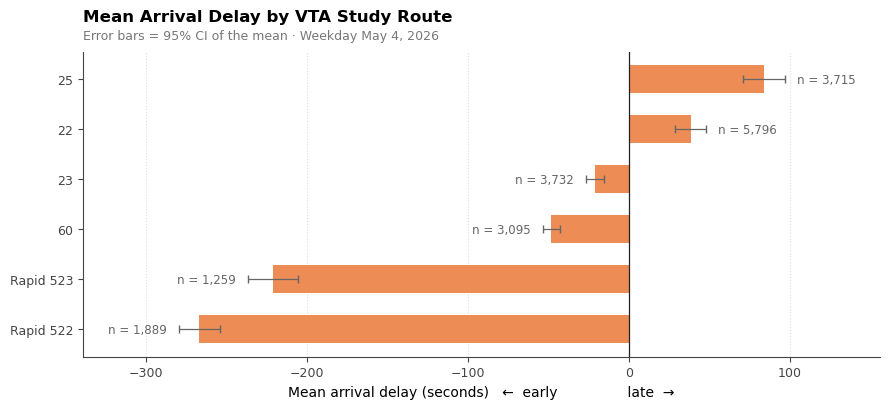

Saved: chart_01_mean_delay_by_route.png


In [4]:
route_stats = []
for rid in SELECTED_ROUTES:
    sub = delay_raw.loc[delay_raw["route_id"].astype(str) == rid, "computed_delay_sec"].dropna()
    if sub.empty: continue
    n = len(sub); mean = sub.mean()
    ci95 = 1.96 * sub.std(ddof=1) / np.sqrt(n)
    route_stats.append({"route_id": rid, "n": n, "mean": mean, "ci95": ci95})

stats_df = pd.DataFrame(route_stats).sort_values("mean")

fig1, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(stats_df["route_id"], stats_df["mean"],
               xerr=stats_df["ci95"], color="#ed8c55", height=0.55,
               edgecolor="none", ecolor="#666", capsize=3,
               error_kw={"elinewidth": 0.9})

x_range = (stats_df["mean"] + stats_df["ci95"]).max() - (stats_df["mean"] - stats_df["ci95"]).min()
offset = x_range * 0.02
for bar, row in zip(bars, stats_df.itertuples()):
    x = bar.get_width()
    tx = x + row.ci95 + offset if x >= 0 else x - row.ci95 - offset
    ha = "left" if x >= 0 else "right"
    ax.text(tx, bar.get_y() + bar.get_height() / 2,
            f"n = {row.n:,}", va="center", ha=ha, fontsize=8.5, color="#666")

ax.axvline(0, color="#222", linewidth=0.9)
ax.set_xlabel("Mean arrival delay (seconds)   ←  early                late  →", fontsize=10)
ax.set_ylabel("")
ax.set_title("Mean Arrival Delay by VTA Study Route", loc="left", pad=22)
ax.text(0, 1.04, "Error bars = 95% CI of the mean · Weekday May 4, 2026",
        transform=ax.transAxes, fontsize=9, color="#777", ha="left")
ax.grid(axis="x", linestyle=":", alpha=0.4, color="#aaa")
ax.set_axisbelow(True)
pad = x_range * 0.15
ax.set_xlim(stats_df["mean"].min() - stats_df["ci95"].max() - pad,
            stats_df["mean"].max() + stats_df["ci95"].max() + pad)
fig1.tight_layout()
fig1.savefig(VIZ / "fig_01_mean_delay_by_route.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: chart_01_mean_delay_by_route.png")


## 3. Figure 2 — Top 20 Delay Hotspot Stops

Horizontal bar chart ranking the 20 stops with the highest mean delay.
Colored by route to reveal which corridors contribute most to the hotspot list.

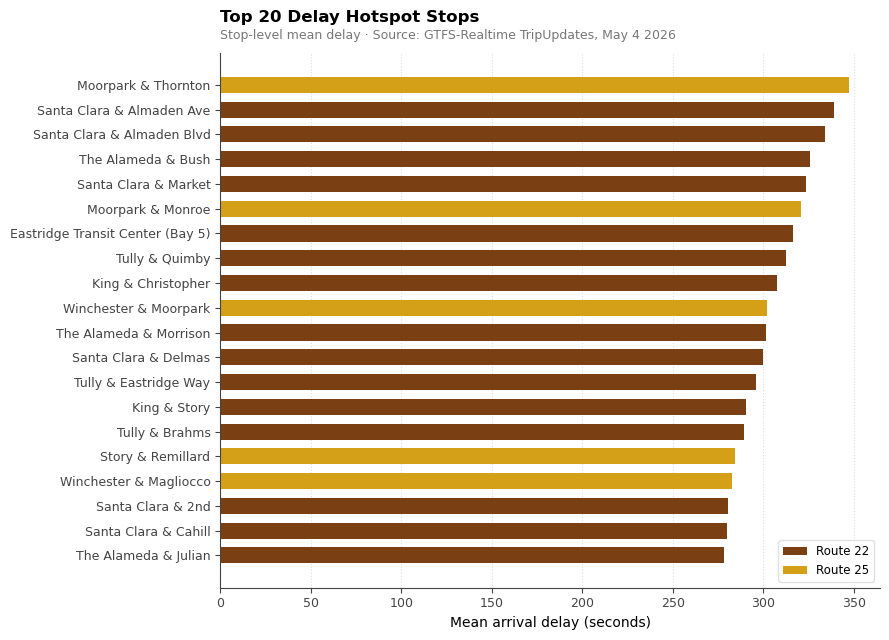

Saved: chart_02_top20_delay_hotspots.png


In [5]:
top20 = gdf.nlargest(20, "mean_delay_sec")[["stop_name", "route_id", "mean_delay_sec"]].iloc[::-1]

fig2, ax = plt.subplots(figsize=(9, 6.5))
colors2 = [ROUTE_COLORS_INT.get(int(r), "#888") for r in top20["route_id"]]
ax.barh(top20["stop_name"], top20["mean_delay_sec"],
        color=colors2, height=0.65, edgecolor="none")

ax.set_xlabel("Mean arrival delay (seconds)", fontsize=10)
ax.set_ylabel("")
ax.set_title("Top 20 Delay Hotspot Stops", loc="left", pad=22)
ax.text(0, 1.025, "Stop-level mean delay · Source: GTFS-Realtime TripUpdates, May 4 2026",
        transform=ax.transAxes, fontsize=9, color="#777", ha="left")

present_routes = top20["route_id"].unique()
legend_elements = [Patch(facecolor=ROUTE_COLORS_INT[int(k)], label=f"Route {int(k)}")
                   for k in sorted(present_routes)]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8.5,
          frameon=True, framealpha=0.9, edgecolor="#ddd")
ax.grid(axis="x", linestyle=":", alpha=0.4, color="#aaa")
ax.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig(VIZ / "fig_02_top20_delay_hotspots.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: chart_02_top20_delay_hotspots.png")

## 4. Figure 3 — Moving Speed Distribution by Route

Box plots of vehicle speed filtered to moving-only pings (> 1 mph).
Box plots show median, IQR, and outliers — more informative than means alone for skewed speed data.

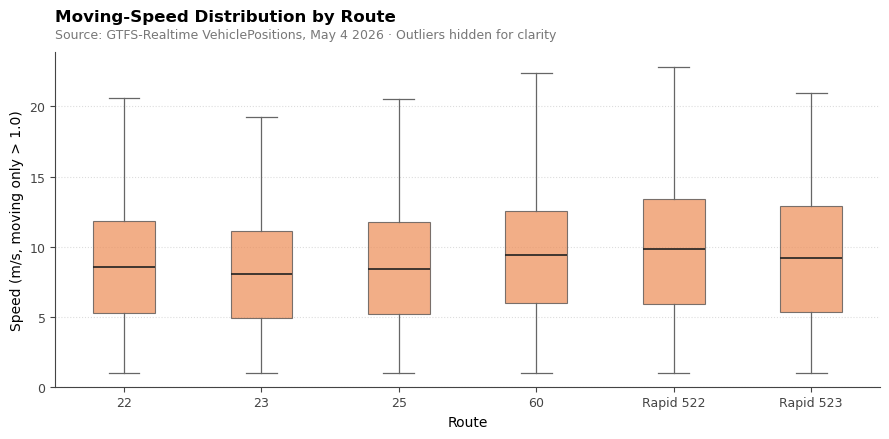

Saved: chart_03_moving_speed_by_route.png


In [6]:
vehicle = pd.read_csv(PROCESSED / "vehicle_points_filtered_buffer250ft.csv")
vehicle["route_id"] = vehicle["route_id"].astype(str)
vehicle["speed"] = pd.to_numeric(vehicle["speed"], errors="coerce")
vehicle = vehicle.dropna(subset=["speed"])
vehicle_moving = vehicle[vehicle["speed"] > 1.0].copy()

route_order = ["22", "23", "25", "60", "Rapid 522", "Rapid 523"]
groups = [vehicle_moving.loc[vehicle_moving["route_id"] == r, "speed"].dropna() for r in route_order]

fig3, ax = plt.subplots(figsize=(9, 4.5))
bp = ax.boxplot(groups, vert=True, patch_artist=True,
                widths=0.45,
                showfliers=False,
                medianprops={"color": "#222", "linewidth": 1.2},
                whiskerprops={"color": "#666", "linewidth": 0.9},
                capprops={"color": "#666", "linewidth": 0.9},
                boxprops={"linewidth": 0.8})
for patch in bp["boxes"]:
    patch.set_facecolor("#ed8c55")
    patch.set_alpha(0.7)
    patch.set_edgecolor("#444")

ax.set_xticklabels(route_order)
ax.set_xlabel("Route", fontsize=10)
ax.set_ylabel("Speed (m/s, moving only > 1.0)", fontsize=10)
ax.set_title("Moving-Speed Distribution by Route", loc="left", pad=22)
ax.text(0, 1.04, "Source: GTFS-Realtime VehiclePositions, May 4 2026 · Outliers hidden for clarity",
        transform=ax.transAxes, fontsize=9, color="#777", ha="left")
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle=":", alpha=0.4, color="#aaa")
ax.set_axisbelow(True)
fig3.tight_layout()
fig3.savefig(VIZ / "fig_03_moving_speed_by_route.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: chart_03_moving_speed_by_route.png")

## 5. Figure 4 — Stop/Idle Share by Route

Bar chart of the share of vehicle pings with speed < 0.5 mph per route.
This serves as a proxy for stop-and-go friction, remaining informative even when delay matching is incomplete.

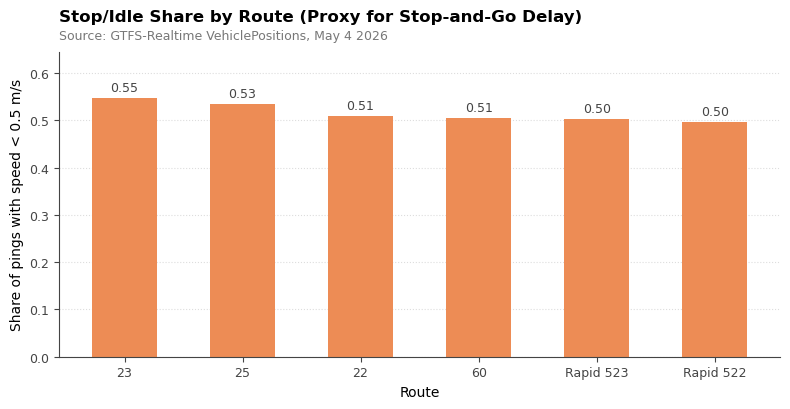

Saved: chart_04_stop_idle_share_by_route.png


In [7]:
vehicle["is_stopped"] = vehicle["speed"] < 0.5
idle_share = (vehicle.groupby("route_id")["is_stopped"].mean()
              .reset_index().rename(columns={"is_stopped": "stop_share"}))
idle_share = idle_share[idle_share["route_id"].isin(route_order)]
idle_share = idle_share.sort_values("stop_share", ascending=False)

fig4, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(idle_share["route_id"], idle_share["stop_share"],
              color="#ed8c55", width=0.55, edgecolor="none")

for bar, val in zip(bars, idle_share["stop_share"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, color="#444")

ax.set_xlabel("Route", fontsize=10)
ax.set_ylabel("Share of pings with speed < 0.5 m/s", fontsize=10)
ax.set_title("Stop/Idle Share by Route (Proxy for Stop-and-Go Delay)", loc="left", pad=22)
ax.text(0, 1.04, "Source: GTFS-Realtime VehiclePositions, May 4 2026",
        transform=ax.transAxes, fontsize=9, color="#777", ha="left")
ax.set_ylim(0, idle_share["stop_share"].max() * 1.18)
ax.grid(axis="y", linestyle=":", alpha=0.4, color="#aaa")
ax.set_axisbelow(True)
fig4.tight_layout()
fig4.savefig(VIZ / "fig_04_stop_idle_share_by_route.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: chart_04_stop_idle_share_by_route.png")

## 6. Figure 5 — Stop Spacing Distribution Map (Interactive)

Plotly Express point map showing stop spacing in feet at each stop.
Color encodes distance to preceding stop (yellow = long, purple = short).
Provides spatial context for RQ1.

In [8]:
def haversine_ft(lat1, lon1, lat2, lon2):
    R = 20902231
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

segments = []
for (rid, did), grp in gdf.groupby(["route_id", "direction_id"]):
    grp = grp.sort_values("stop_sequence").reset_index(drop=True)
    for i in range(1, len(grp)):
        lat1, lon1 = grp.iloc[i-1]["lat"], grp.iloc[i-1]["lon"]
        lat2, lon2 = grp.iloc[i]["lat"], grp.iloc[i]["lon"]
        geo_dist = haversine_ft(lat1, lon1, lat2, lon2)
        if 50 < geo_dist < 5000:
            segments.append({
                "lat1": lat1, "lon1": lon1, "lat2": lat2, "lon2": lon2,
                "spacing_ft": geo_dist,
                "route_id": rid,
            })

seg_df = pd.DataFrame(segments)
print(f"Segments: {len(seg_df)} | Range: "
      f"{seg_df['spacing_ft'].min():.0f}–{seg_df['spacing_ft'].max():.0f} ft")

Segments: 562 | Range: 348–4899 ft


In [9]:
routes = gpd.read_file("../data/raw/Routes_October_2025.geojson")
routes = routes.to_crs("EPSG:4326")

LOCAL_ROUTES = [22, 23, 25, 60]
RAPID_ROUTES = [522, 523]

bins       = [0, 600, 1000, 1500, 2500, 1e9]
labels     = ["< 600 ft", "600–1000 ft", "1000–1500 ft", "1500–2500 ft", "> 2500 ft"]
colors     = ["#a50f15", "#de2d26", "#fc9272", "#bdbdbd", "#e0e0e0"]
bin_widths = {"< 600 ft": 5, "600–1000 ft": 4, "1000–1500 ft": 3,
              "1500–2500 ft": 2.5, "> 2500 ft": 2}

seg_df["bin"] = pd.cut(seg_df["spacing_ft"], bins=bins, labels=labels)

def make_spacing_map(seg_df, route_list, title_label):
    sub_seg    = seg_df[seg_df["route_id"].isin(route_list)].copy()
    sub_stops  = gdf[gdf["route_id"].isin(route_list)]
    sub_routes = routes[routes["lineabbr"].isin([str(r) for r in route_list])]

    fig = go.Figure()

    route_lats, route_lons = [], []
    for _, row in sub_routes.iterrows():
        geom  = row.geometry
        parts = [geom] if geom.geom_type == "LineString" else list(geom.geoms)
        for part in parts:
            coords = list(part.coords)
            route_lats.extend([c[1] for c in coords] + [None])
            route_lons.extend([c[0] for c in coords] + [None])

    fig.add_trace(go.Scattermap(
        lat=route_lats, lon=route_lons,
        mode="lines",
        line=dict(width=1.5, color="rgba(255,255,255,0.2)"),
        hoverinfo="skip",
        showlegend=False,
    ))

    for label, color in zip(labels, colors):
        sub = sub_seg[sub_seg["bin"] == label]
        if sub.empty:
            continue
        lats, lons = [], []
        for _, row in sub.iterrows():
            lats.extend([row["lat1"], row["lat2"], None])
            lons.extend([row["lon1"], row["lon2"], None])
        fig.add_trace(go.Scattermap(
            lat=lats, lon=lons, mode="lines",
            line=dict(width=bin_widths[label], color=color),
            name=label,
            hoverinfo="skip",
        ))

    fig.add_trace(go.Scattermap(
        lat=sub_stops["lat"], lon=sub_stops["lon"],
        mode="markers",
        marker=dict(size=3, color="yellow", opacity=0.9),
        text=sub_stops.apply(
            lambda r: (f"<b>{r['stop_name']}</b><br>Route {r['route_id']}<br>"
                       f"Spacing: {r['spacing_ft']:.0f} ft"
                       if pd.notna(r['spacing_ft'])
                       else f"<b>{r['stop_name']}</b><br>Route {r['route_id']}"),
            axis=1),
        hoverinfo="text",
        showlegend=False,
    ))

    fig.update_layout(
        map=dict(
            style="white-bg",
            layers=[dict(
                below="traces",
                sourcetype="raster",
                source=["https://a.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}.png"],
                opacity=1.0,
            )],
            center={"lat": sub_stops["lat"].mean(), "lon": sub_stops["lon"].mean()},
            zoom=10,
        ),
        title=f"Stop Spacing Along VTA Study Corridors — {title_label}<br>"
              f"<sup>Each segment colored by straight-line distance between consecutive stops · "
              f"Darker red = shorter spacing, Lighter = longer spacing</sup>",
        legend=dict(title="Spacing", x=0.02, y=0.98,
                    bgcolor="rgba(255,255,255,0.85)",
                    bordercolor="#ddd", borderwidth=1),
        margin=dict(l=0, r=0, t=70, b=0),
        height=900,
    )
    return fig

fig7a = make_spacing_map(seg_df, LOCAL_ROUTES, "Local Routes (22/23/25/60)")
fig7b = make_spacing_map(seg_df, RAPID_ROUTES, "Rapid Routes (522/523)")

fig7a.show()
fig7a.write_html(VIZ / "fig_05a_map_stop_spacing_local.html", config={"scrollZoom": True})
print("Saved: fig_05a_map_stop_spacing_local.html")

fig7b.show()
fig7b.write_html(VIZ / "fig_05b_map_stop_spacing_rapid.html", config={"scrollZoom": True})
print("Saved: fig_05b_map_stop_spacing_rapid.html")

Saved: fig_05a_map_stop_spacing_local.html


Saved: fig_05b_map_stop_spacing_rapid.html


## 7. Figure 6 — Stop/Idle Share Grid: Low-Speed Hotspots (Interactive)

1200-ft grid aggregation of vehicle position pings.
Bubble size = share of near-stopped pings (speed < 0.5 mph); color = mean speed.
Grid aggregation reduces overplotting from ~80k raw GPS points.

In [15]:
GRID_FT = 1200
STOP_TH = 0.5
MIN_PINGS = 20

veh = pd.read_csv(PROCESSED / "vehicle_points_filtered_buffer250ft.csv")
veh["speed"] = pd.to_numeric(veh["speed"], errors="coerce")
veh = veh.dropna(subset=["lat", "lon", "speed"])
veh = veh[veh["speed"] >= 0]

veh_gdf = gpd.GeoDataFrame(
    veh,
    geometry=gpd.points_from_xy(veh["lon"], veh["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:2227")

veh_gdf["gx"] = (veh_gdf.geometry.x // GRID_FT) * GRID_FT
veh_gdf["gy"] = (veh_gdf.geometry.y // GRID_FT) * GRID_FT
veh_gdf["is_stop"] = veh_gdf["speed"] < STOP_TH

grid = (
    veh_gdf.groupby(["gx", "gy"])
    .agg(mean_speed=("speed", "mean"),
         stop_share=("is_stop", "mean"),
         n=("speed", "size"))
    .reset_index()
)
grid = grid[grid["n"] >= MIN_PINGS].copy()

grid_gdf = gpd.GeoDataFrame(
    grid,
    geometry=gpd.points_from_xy(grid["gx"], grid["gy"]),
    crs="EPSG:2227",
).to_crs("EPSG:4326")
grid_gdf["lat"] = grid_gdf.geometry.y
grid_gdf["lon"] = grid_gdf.geometry.x

fig8 = px.scatter_map(
    grid_gdf,
    lat="lat", lon="lon",
    size="n",
    color="mean_speed",
    color_continuous_scale="RdBu",
    zoom=10,
    center={"lat": grid_gdf["lat"].mean(), "lon": grid_gdf["lon"].mean()},
    hover_data={
        "mean_speed": ":.2f",
        "stop_share": ":.2f",
        "n": True,
        "lat": False, "lon": False,
    },
    labels={"mean_speed": "Mean Speed (m/s)",
            "stop_share": "Stop Share",
            "n": "Pings"},
    title=f"Grid Summary ({GRID_FT}ft cells): Low-Speed Hotspots<br>"
          f"<sup>Color = mean speed (m/s) · Bubble size = number of vehicle pings · "
          f"Stop threshold = speed < {STOP_TH} m/s · May 4 2026</sup>",
)
fig8.update_layout(
    map_style="carto-darkmatter",
    coloraxis_colorbar=dict(title="Mean Speed (m/s)"),
    margin=dict(l=0, r=0, t=70, b=0),
    height=650,
)
fig8.show()
fig8.write_html(VIZ / "fig_06_map_grid_stopshare_1200ft.html", config={"scrollZoom": True})
print("Saved: map_grid_stopshare_1200ft.html")

Saved: map_grid_stopshare_1200ft.html


## 8. Figure 7 — Stop Spacing vs. Mean Delay

Scatter plot testing RQ1. Points colored by route with OLS fit line.
Spearman correlation is reported alongside Pearson because Route 25 contains long-tail spacing outliers
from freeway-gap segments that distort the linear fit.

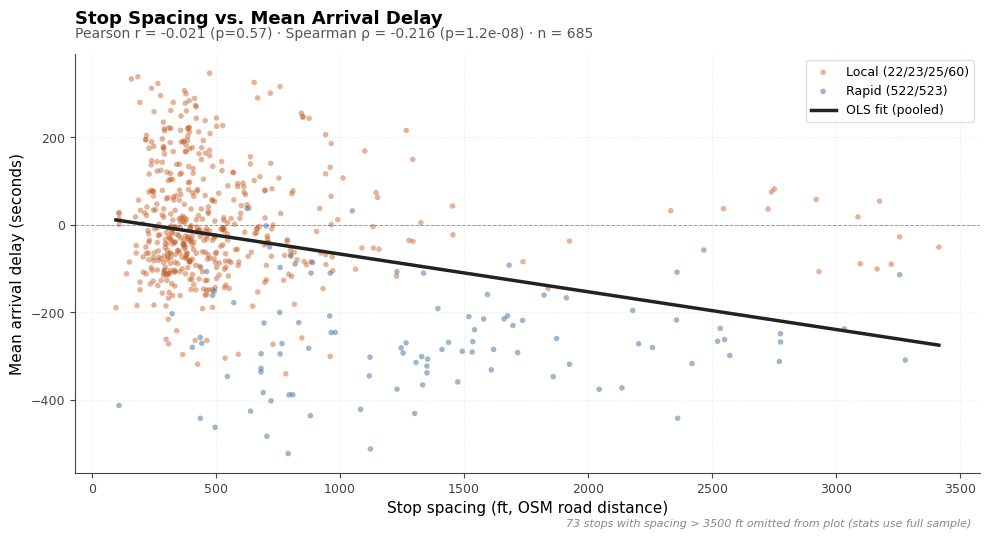

Saved: fig_07


In [11]:
spacing_full = gdf[gdf["spacing_ft"] > 0].copy()
spacing_full["route_type"] = np.where(
    spacing_full["route_id"].astype(str).str.contains("522|523"), "Rapid", "Local")

pearson_r5, pearson_p5 = stats.pearsonr(spacing_full["spacing_ft"], spacing_full["mean_delay_sec"])
spearman_r5, spearman_p5 = stats.spearmanr(spacing_full["spacing_ft"], spacing_full["mean_delay_sec"])
n5 = len(spacing_full)

spacing_plot = spacing_full[spacing_full["spacing_ft"] <= 3500]
n_capped5 = len(spacing_full) - len(spacing_plot)

fig5, ax = plt.subplots(figsize=(10, 5.5))

# Local vs Rapid (two groups)
for label, color, marker_size in [("Local (22/23/25/60)", "#c25a1f", 16),
                                   ("Rapid (522/523)", "#2c5e8f", 16)]:
    sub = spacing_plot[spacing_plot["route_type"] == label.split(" ")[0]]
    ax.scatter(sub["spacing_ft"], sub["mean_delay_sec"],
               s=marker_size, alpha=0.45, color=color, edgecolor="none",
               label=label)

ax.axhline(0, color="#444", linewidth=0.7, linestyle="--", alpha=0.5)

slope5, intercept5 = np.polyfit(spacing_plot["spacing_ft"], spacing_plot["mean_delay_sec"], 1)
xs5 = np.linspace(spacing_plot["spacing_ft"].min(), spacing_plot["spacing_ft"].max(), 100)
ax.plot(xs5, slope5 * xs5 + intercept5,
        color="#222", linewidth=2.5, label="OLS fit (pooled)")

ax.set_xlabel("Stop spacing (ft, OSM road distance)", fontsize=11)
ax.set_ylabel("Mean arrival delay (seconds)", fontsize=11)
ax.set_title("Stop Spacing vs. Mean Arrival Delay", loc="left", pad=22,
             fontsize=13, weight="bold")
ax.text(0, 1.04,
        f"Pearson r = {pearson_r5:+.3f} (p={pearson_p5:.2g}) · "
        f"Spearman ρ = {spearman_r5:+.3f} (p={spearman_p5:.2g}) · n = {n5}",
        transform=ax.transAxes, fontsize=10, color="#555", ha="left")
if n_capped5:
    ax.text(0.99, -0.13,
            f"{n_capped5} stops with spacing > 3500 ft omitted from plot (stats use full sample)",
            transform=ax.transAxes, fontsize=8, ha="right", style="italic", color="#888")
ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9, edgecolor="#ddd")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, linestyle=":", color="#aaa")
ax.set_axisbelow(True)
fig5.tight_layout()
fig5.savefig(VIZ / "fig_07_scatter_spacing_vs_delay.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: fig_07")

## 9. Figure 8 — Daily Boardings vs. Mean Delay

Scatter plot testing RQ2. Log scale on x-axis because boardings are right-skewed.
Negative association reflects that high-ridership stops are concentrated on Rapid 522/523
corridors that run ahead of conservative schedules.

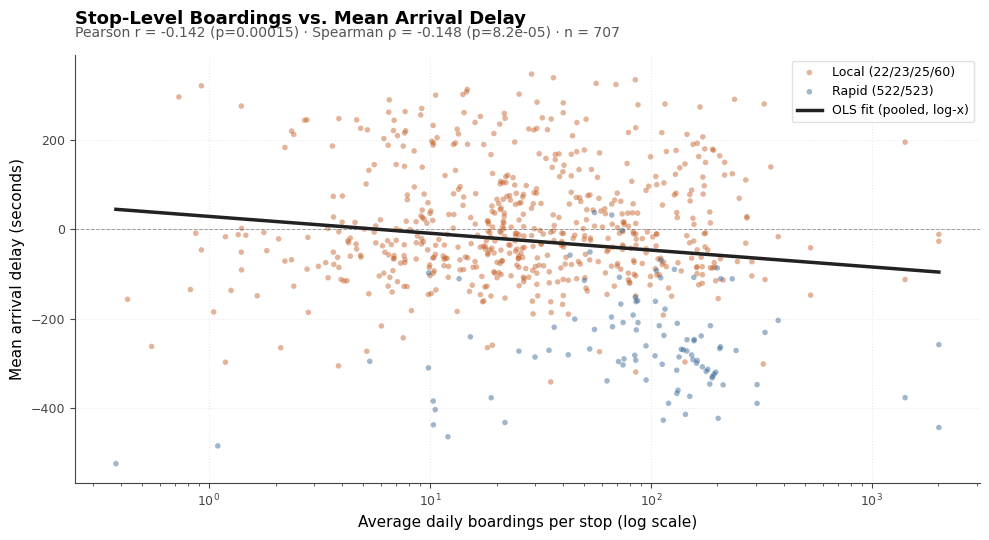

Saved: fig_08


In [12]:
boarding_full = gdf[gdf["boardings"] > 0].copy()
boarding_full["route_type"] = np.where(
    boarding_full["route_id"].astype(str).str.contains("522|523"), "Rapid", "Local")

pearson_r6, pearson_p6 = stats.pearsonr(boarding_full["boardings"], boarding_full["mean_delay_sec"])
spearman_r6, spearman_p6 = stats.spearmanr(boarding_full["boardings"], boarding_full["mean_delay_sec"])
n6 = len(boarding_full)

fig6, ax = plt.subplots(figsize=(10, 5.5))

for label, color in [("Local (22/23/25/60)", "#c25a1f"),
                     ("Rapid (522/523)", "#2c5e8f")]:
    sub = boarding_full[boarding_full["route_type"] == label.split(" ")[0]]
    ax.scatter(sub["boardings"], sub["mean_delay_sec"],
               s=16, alpha=0.45, color=color, edgecolor="none", label=label)

ax.axhline(0, color="#444", linewidth=0.7, linestyle="--", alpha=0.5)

log_x6 = np.log10(boarding_full["boardings"])
slope6, intercept6 = np.polyfit(log_x6, boarding_full["mean_delay_sec"], 1)
xs6 = np.linspace(log_x6.min(), log_x6.max(), 100)
ax.plot(10 ** xs6, slope6 * xs6 + intercept6,
        color="#222", linewidth=2.5, label="OLS fit (pooled, log-x)")

ax.set_xscale("log")
ax.set_xlabel("Average daily boardings per stop (log scale)", fontsize=11)
ax.set_ylabel("Mean arrival delay (seconds)", fontsize=11)
ax.set_title("Stop-Level Boardings vs. Mean Arrival Delay", loc="left", pad=22,
             fontsize=13, weight="bold")
ax.text(0, 1.04,
        f"Pearson r = {pearson_r6:+.3f} (p={pearson_p6:.2g}) · "
        f"Spearman ρ = {spearman_r6:+.3f} (p={spearman_p6:.2g}) · n = {n6}",
        transform=ax.transAxes, fontsize=10, color="#555", ha="left")
ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9, edgecolor="#ddd")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25, linestyle=":", color="#aaa")
ax.set_axisbelow(True)
fig6.tight_layout()
fig6.savefig(VIZ / "fig_08_scatter_boardings_vs_delay.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: fig_08")


## 10. Figure 9 — Ridership & Delay Bubble Map (Interactive)

Plotly Express bubble map. Bubble size = avg daily boardings; color = mean arrival delay.
Directly addresses RQ2 in spatial context. Red = late, green = early.

In [13]:
fig_bubble = px.scatter_map(         
    gdf,
    lat="lat",
    lon="lon",
    size="boardings_rounded",
    color="mean_delay_sec",
    color_continuous_scale=[
        [0.0,  "#1a6faf"],  
        [0.35, "#74b9e7"],  
        [0.5,  "#f5f5f5"], 
        [0.65, "#f4a582"], 
        [1.0,  "#c0392b"], 
    ],
    size_max=30,
    zoom=10,
    center={"lat": gdf["lat"].mean(), "lon": gdf["lon"].mean()},
    hover_name="stop_name",
    hover_data={
        "route_label":       True,
        "boardings_rounded": True,
        "mean_delay_sec":    True,
        "spacing_m":         True,
        "lat":               False,
        "lon":               False,
    },
    labels={
        "mean_delay_sec":    "Mean Delay (sec)",
        "boardings_rounded": "Avg Daily Boardings",
        "spacing_m":         "Stop Spacing (m)",
        "route_label":       "Route",
    },
    title=(
        "Figure 9 — Stop-Level Ridership and Arrival Delay<br>"
        "<sup>VTA Routes 22/522/23/523/25/60 | Weekday | May 2026 | "
        "Bubble size = avg daily boardings · "
        "Blue = Early Arrival · Red = Late Arrival</sup>"
    ),
)

fig_bubble.update_layout(
    map_style="carto-darkmatter",      
    coloraxis_colorbar=dict(
        title="Arrival Delay (sec)",
        ticksuffix=" s",
        tickvals=[-400, -200, 0, 200, 400],
        ticktext=["-400 s (Early)", "-200 s", "0 (On Time)", "+200 s", "+400 s (Late)"],
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
    font=dict(family="Arial", size=12),
)

fig_bubble.show()
fig_bubble.write_html(
    "../visualizations/fig_09_map_bubble_ridership_delay.html",
    config={"scrollZoom": True}      
)
print("Saved: ../visualizations/map_bubble_ridership_delay.html")

Saved: ../visualizations/map_bubble_ridership_delay.html


## 11. Figure 10 — Delay Hotspots Overlaid with ADT (Interactive)

Two-layer Plotly map addressing RQ3.
Red markers = delay hotspot stops (top 25%); blue circles = San José ADT counters sized by volume.
Spatial overlap suggests locations where road traffic contributes to bus delay.

In [14]:
adt_df = pd.read_csv("../data/processed/selected_sj_adt.csv")
adt_df["geometry"] = adt_df["geometry"].apply(wkt.loads)
adt_gdf = gpd.GeoDataFrame(adt_df, geometry="geometry", crs="EPSG:2227")
adt_gdf = adt_gdf.to_crs("EPSG:4326")
adt_df["lat"] = adt_gdf.geometry.y
adt_df["lon"] = adt_gdf.geometry.x
adt_df = adt_df.dropna(subset=["adt"])

LAT_COL = "lat"
LON_COL = "lon"
ADT_COL = "adt"

delay_threshold = gdf["mean_delay_sec"].quantile(0.75)
hotspots = gdf[gdf["mean_delay_sec"] >= delay_threshold].copy()
print(f"Delay hotspot threshold (75th percentile): {delay_threshold:.1f} sec")
print(f"Number of hotspot stops: {len(hotspots)}")

fig_adt = go.Figure()

fig_adt.add_trace(go.Scattermap(
    lat=adt_df[LAT_COL],
    lon=adt_df[LON_COL],
    mode="markers",
    marker=dict(
        size=adt_df[ADT_COL] / adt_df[ADT_COL].max() * 25 + 5,
        color="cornflowerblue",
        opacity=0.3,
    ),
    text=adt_df.apply(
        lambda r: f"ADT: {int(r[ADT_COL]):,} vehicles/day", axis=1
    ),
    hoverinfo="text",
    name="Traffic Volume (ADT)",
))

fig_adt.add_trace(go.Scattermap(
    lat=hotspots["lat"],
    lon=hotspots["lon"],
    mode="markers",
    marker=dict(
        size=12,
        color=hotspots["mean_delay_sec"],
        colorscale="Reds",
        cmin=delay_threshold,
        cmax=hotspots["mean_delay_sec"].max(),
        colorbar=dict(
            title="Mean Delay (sec)",
            x=1.0,
        ),
        opacity=0.9,
    ),
    text=hotspots.apply(
        lambda r: (
            f"{r['stop_name']}<br>"
            f"Route {r['route_id']}<br>"
            f"Delay: {r['mean_delay_sec']:.0f} sec<br>"
            f"Boardings: {r['boardings_rounded']:.0f}/day"
        ),
        axis=1
    ),
    hoverinfo="text",
    name="Delay Hotspot (top 25%)",
))

fig_adt.update_layout(
    map_style="carto-darkmatter",
    map_zoom=11,
    map_center={
        "lat": gdf["lat"].mean(),
        "lon": gdf["lon"].mean()
    },
    title=(
        "Figure 10 — Delay Hotspots and Road Traffic Volume (ADT)<br>"
        "<sup>VTA Routes 22/522/23/523/25/60 | "
        "Red = high-delay stops (top 25%); "
        "Gray = ADT counters sized by vehicle volume | San José, CA</sup>"
    ),
    legend=dict(x=0, y=1, bgcolor="rgba(255,255,255,0.8)"),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
    font=dict(family="Arial", size=12),
)

fig_adt.show()
fig_adt.write_html(
    "../visualizations/fig_10_map_delay_hotspot_adt.html",
    config={"scrollZoom": True}
)
print("Saved: ../visualizations/fig_10_map_delay_hotspot_adt.html")

Delay hotspot threshold (75th percentile): 66.0 sec
Number of hotspot stops: 178


Saved: ../visualizations/fig_10_map_delay_hotspot_adt.html
